In [12]:
path = r"C:/Users/rasmu/OneDrive/Skrivebord/1-NytdropPython/4.year/AppliedML2026/Examproject/3DSC/superconductors_3D/data/final/MP"
path_red = r"C:/Users/rasmu/OneDrive/Skrivebord/1-NytdropPython/4.year/AppliedML2026/Examproject/3DSC/superconductors_3D"
import numpy as np
import pandas as pd

from pymatgen.core import Structure
import matgl
from matgl.ext.pymatgen import Structure2Graph

In [13]:
data = pd.read_csv(path + "\\3DSC_MP.csv", skiprows=1)
#print(data.columns)
print(data.loc[0,'tc'])
print(data.loc[0,'cif'])

2.64
data/final/MP/cifs/Ag0.02Ge2Pd1.98Sr1-MP-mp-978986-synth_doped.cif


In [14]:

structure = Structure.from_file(path_red +'/' + data.loc[0,'cif'])
structure

Structure Summary
Lattice
    abc : 4.438672 4.438672 6.03054834
 angles : 111.59328752 111.59328752 89.99999998999999
 volume : 101.4530475362769
      A : 4.127164255059669 0.0 -1.6335006383046717
      B : -0.6465272925912613 4.076209912182743 -1.6335006383046717
      C : 0.0 0.0 6.03054834
    pbc : True True True
PeriodicSite: Sr0 (Sr) (0.0, 0.0, 0.0) [0.0, 0.0, 0.0]
PeriodicSite: Ge1 (Ge) (1.29, 1.511, 3.259) [0.3706, 0.3706, 0.7411]
PeriodicSite: Ge1 (Ge) (2.191, 2.566, -0.4953) [0.6294, 0.6294, 0.2589]
PeriodicSite: Ag3 (Ag:0.01, Pd:0.99) (0.5469, 3.057, 1.382) [0.25, 0.75, 0.5]
PeriodicSite: Ag3 (Ag:0.01, Pd:0.99) (2.934, 1.019, 1.382) [0.75, 0.25, 0.5]

In [ ]:
import numpy as np
import torch
from torch_geometric.data import Data
from pymatgen.core import Structure

# Gaussian basis expansion for bond distances (like CGCNN)
def gaussian_expansion(distances, dmin=0, dmax=8, steps=40):
    filters = np.linspace(dmin, dmax, steps)
    sigma = (dmax - dmin) / steps
    return np.exp(-((distances[:, None] - filters[None, :]) ** 2) / sigma ** 2)

def get_atom_features(structure):
    features = []
    for site in structure:
        
        if site.is_ordered:
            elem = site.specie
            features.append([
                float(elem.Z),
                float(elem.atomic_mass),
                float(elem.atomic_radius) if elem.atomic_radius else 0.0,
                float(elem.X) if elem.X else 0.0,          # electronegativity
                float(elem.row),                            # period in periodic table
                float(elem.group),                         # group in periodic table
                1.0,                                        # occupancy (fully occupied)
                0.0,                                        # disorder: 0 = pure site
            ])
        else:
            Z, mass, radius, X, row, group = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
            # measure of disorder (like entropy)
            occupancies = list(site.species.values())
            disorder = -sum(o * np.log(o + 1e-9) for o in occupancies)
            
            for elem, occ in site.species.items():
                Z      += occ * float(elem.Z)
                mass   += occ * float(elem.atomic_mass)
                radius += occ * (float(elem.atomic_radius) if elem.atomic_radius else 0.0)
                X      += occ * (float(elem.X) if elem.X else 0.0)
                row    += occ * float(elem.row)
                group  += occ * float(elem.group)

            features.append([Z, mass, radius, X, row, group,
                              max(occupancies),  # dominant occupancy
                              disorder])         # site disorder

    return np.array(features, dtype=np.float32)

def structure_to_graph(structure, target, cutoff=8.0):
    # Node features
    atom_feats = get_atom_features(structure)
    x = torch.tensor(atom_feats, dtype=torch.float)

    # Find neighbors within cutoff
    all_neighbors = structure.get_all_neighbors(cutoff, include_index=True)

    edge_src, edge_dst, edge_distances = [], [], []
    for i, neighbors in enumerate(all_neighbors):
        for neighbor in neighbors:
            edge_src.append(i)
            edge_dst.append(neighbor[2])       # index of neighbor atom
            edge_distances.append(neighbor[1]) # distance

    edge_index = torch.tensor(np.array([edge_src, edge_dst]), dtype=torch.long)

    # Edge features: Gaussian expanded distances
    distances = np.array(edge_distances)
    edge_attr = torch.tensor(gaussian_expansion(distances), dtype=torch.float)
    #print(distances, edge_attr)
    # Target value
    y = torch.tensor([target], dtype=torch.float)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    return data


structure = Structure.from_file(path_red +'/' + data.loc[0,'cif'])
graph = structure_to_graph(structure, target=2.64, cutoff=8.0)
print(structure.get_all_neighbors(8, include_index=True))

In [92]:
structure = Structure.from_file(path_red +'/' + data.loc[0,'cif'])
graph = structure_to_graph(structure, target=2.64, cutoff=8.0)
print(structure.get_all_neighbors(8, include_index=True))
#get_atom_features(structure)

[[PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-0.5469, -3.057, -1.382) [-0.25, -0.75, -0.5], PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-2.934, -1.019, -1.382) [-0.75, -0.25, -0.5], PeriodicNeighbor: Ge1 (Ge) (-1.29, -1.511, -3.259) [-0.3706, -0.3706, -0.7411], PeriodicNeighbor: Sr0 (Sr) (-3.481, -4.076, -2.764) [-1.0, -1.0, -1.0], PeriodicNeighbor: Ge1 (Ge) (-2.191, -2.566, -5.535) [-0.6294, -0.6294, -1.259], PeriodicNeighbor: Ge1 (Ge) (-0.6433, -5.587, -1.625) [-0.3706, -1.371, -0.7411], PeriodicNeighbor: Ge1 (Ge) (-1.544, -6.642, -3.902) [-0.6294, -1.629, -1.259], PeriodicNeighbor: Ge1 (Ge) (-5.417, -1.511, -1.625) [-1.371, -0.3706, -0.7411], PeriodicNeighbor: Ge1 (Ge) (-6.318, -2.566, -3.902) [-1.629, -0.6294, -1.259], PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-0.5469, -3.057, 4.649) [-0.25, -0.75, 0.5], PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-2.934, -1.019, 4.649) [-0.75, -0.25, 0.5], PeriodicNeighbor: Ge1 (Ge) (-1.29, -1.511, 2.772) [-0.3706, -0.3706, 0.2589], PeriodicNeighbor: G

In [107]:
from pymatgen.core import Structure

graphs = []
for i, row in data.iterrows():
    try:
        structure = Structure.from_file(path_red + '/' + row['cif'])
        #print(structure)
        graph = structure_to_graph(structure, target=row['tc'], cutoff=8.0)
        graphs.append(graph)
    except Exception as e:
        print(f"Skipping row {i}: {e}")

print(f"Built {len(graphs)} graphs")
print(graphs[0])  # inspect first graph
graphs = torch.load('crystal_graphs.pt', weights_only=False)

c:\Users\rasmu\anaconda3\envs\fresh_env\Lib\site-packages\pymatgen\core\structure.py:3172: UserWarning: Issues encountered while parsing CIF: 20 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
c:\Users\rasmu\anaconda3\envs\fresh_env\Lib\site-packages\pymatgen\core\structure.py:3172: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
c:\Users\rasmu\anaconda3\envs\fresh_env\Lib\site-packages\pymatgen\core\structure.py:3172: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
c:\Users\rasmu\anaconda3\envs\fresh_env\Lib\site-packages\pymatgen\core\structure.py:3172: UserWarning: Issues encountered while par

Built 5773 graphs
Data(x=[5, 8], edge_index=[2, 480], edge_attr=[480, 40], y=[1])


In [94]:
import networkx as nx
import matplotlib.pyplot as plt
from pymatgen.core import Element

def draw_crystal_graph(data, structure, title="Crystal Graph"):
    
    # Build networkx graph
    G = nx.Graph()
    
    # Add nodes
    num_atoms = data.x.shape[0]
    for i in range(num_atoms):
        G.add_node(i)
    
    # Add edges (avoid duplicate edges since graph is undirected)
    edge_index = data.edge_index.numpy()
    for i in range(edge_index.shape[1]):
        src, dst = edge_index[0, i], edge_index[1, i]
        if src < dst:  # avoid duplicates
            G.add_edge(src, dst)
    
    # Get atom labels and colors for each node
    labels = {}
    colors = []
    color_map = {}  # map element symbol to color
    cmap = plt.cm.get_cmap("tab20")
    color_idx = 0

    for i, site in enumerate(structure):
        if site.is_ordered:
            symbol = site.specie.symbol
        else:
            # Use dominant element for label
            symbol = max(site.species, key=site.species.get).symbol
            symbol = symbol + "*"  # mark doped sites with asterisk
        
        labels[i] = symbol
        
        if symbol not in color_map:
            color_map[symbol] = cmap(color_idx % 20)
            color_idx += 1
        colors.append(color_map[symbol])
    
    # Draw
    fig, ax = plt.subplots(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)
    
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=800, ax=ax)
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="white", ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.5, ax=ax)
    
    # Legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color, markersize=10, label=symbol)
        for symbol, color in color_map.items()
    ]
    ax.legend(handles=legend_elements, loc="upper right")
    ax.set_title(f"{title}\n{data.x.shape[0]} atoms, {G.number_of_edges()} bonds, Tc={data.y.item():.1f} K")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

Full Formula (Al2 V6)
Reduced Formula: AlV3
abc   :   4.809439   4.809439   4.809439
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (8)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Al    0     0     0
  1  Al    0.5   0.5   0.5
  2  V     0     0.5   0.25
  3  V     0     0.5   0.75
  4  V     0.25  0     0.5
  5  V     0.75  0     0.5
  6  V     0.5   0.25  0
  7  V     0.5   0.75  0 data/final/MP/cifs/Al0.25V0.75-MP-mp-1387.cif


C:\Users\rasmu\AppData\Local\Temp\ipykernel_48744\1556959492.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


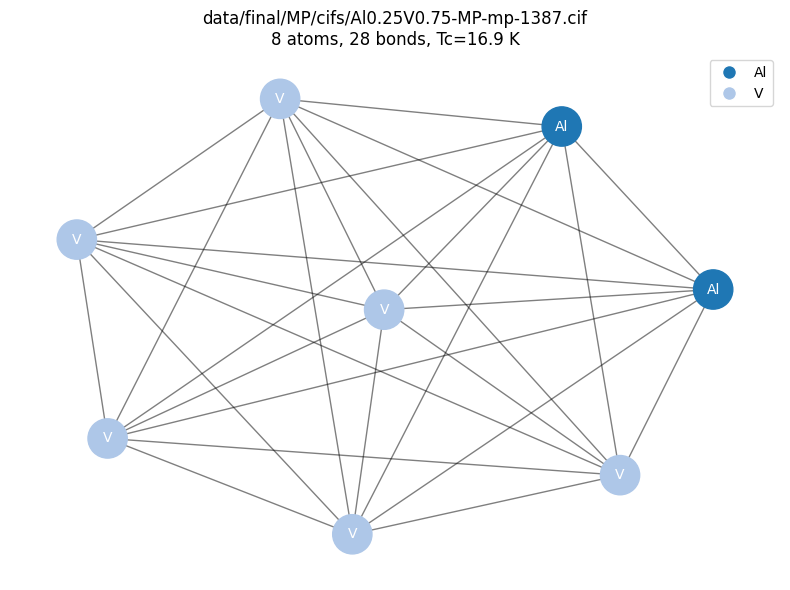

In [101]:
i = 100
structure = Structure.from_file(path_red + '/' + data.loc[i, 'cif'])
print(structure,data.loc[i, 'cif'])
graph = structure_to_graph(structure, target=data.loc[i, 'tc'])
draw_crystal_graph(graph, structure, title=data.loc[i, 'cif'])

In [109]:
import torch
import torch.nn as nn
from torch_geometric.nn import CGConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch.optim.lr_scheduler import StepLR
import numpy as np

class CGCNN(nn.Module):
    def __init__(self, node_features=8, edge_features=40, 
                 hidden_dim=64, num_conv_layers=3, dropout=0.1):
        super(CGCNN, self).__init__()
        
        # Initial embedding of node features
        self.node_embedding = nn.Linear(node_features, hidden_dim)
        
        # Graph convolutional layers
        self.conv_layers = nn.ModuleList([
            CGConv(hidden_dim, dim=edge_features, batch_norm=True)
            for _ in range(num_conv_layers)
        ])
        
        self.dropout = nn.Dropout(dropout)
        
        # Readout MLP
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )
        
        # Embed node features
        x = self.node_embedding(x)
        x = torch.relu(x)
        
        # Graph convolutions
        for conv in self.conv_layers:
            x = conv(x, edge_index, edge_attr)
            x = torch.relu(x)
            x = self.dropout(x)
        
        # Global pooling: aggregate all atoms into one vector
        x = global_mean_pool(x, batch)
        
        # Predict
        out = self.fc(x)
        return out.squeeze(-1)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        
        y = batch.y.view(-1)  # flatten to 1D
        
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)
            
            # Use squeeze(-1) to only squeeze the last dimension
            y = batch.y.view(-1)  # flatten to 1D regardless of shape
            
            loss = criterion(pred, y)
            total_loss += loss.item()
            preds.extend(pred.cpu().numpy())
            targets.extend(y.cpu().numpy())
    
    mae = np.mean(np.abs(np.array(preds) - np.array(targets)))
    return total_loss / len(loader), mae


def train_cgcnn(graphs, test_size=0.2, val_size=0.1,
                hidden_dim=64, num_conv_layers=3,
                epochs=100, batch_size=32, lr=1e-3):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Split dataset
    n = len(graphs)
    n_test  = int(n * test_size)
    n_val   = int(n * val_size)
    n_train = n - n_test - n_val

    train_graphs = graphs[:n_train]
    val_graphs   = graphs[n_train:n_train + n_val]
    test_graphs  = graphs[n_train + n_val:]

    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_graphs,   batch_size=batch_size)
    test_loader  = DataLoader(test_graphs,  batch_size=batch_size)

    # Model, optimizer, loss
    node_features = graphs[0].x.shape[1]
    edge_features = graphs[0].edge_attr.shape[1]

    model = CGCNN(
        node_features=node_features,
        edge_features=edge_features,
        hidden_dim=hidden_dim,
        num_conv_layers=num_conv_layers
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=30, gamma=0.5)
    criterion = nn.MSELoss()

    # Training loop
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_mae = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:03d} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Val MAE: {val_mae:.4f}")

    # Load best model and evaluate on test set
    model.load_state_dict(best_model_state)
    test_loss, test_mae = evaluate(model, test_loader, criterion, device)
    print(f"\nTest Loss: {test_loss:.4f} | Test MAE: {test_mae:.4f}")

    return model, test_mae

In [ ]:
graphs = torch.load('crystal_graphs.pt', weights_only=False)


# Train
model, test_mae = train_cgcnn(
    graphs,
    hidden_dim=64,
    num_conv_layers=3,
    epochs=300,
    batch_size=32,
    lr=1e-3,
    #dropout=0.1  # light regularization
)

# Save trained model
torch.save(model.state_dict(), 'cgcnn_model.pt')

Using device: cpu
Epoch 010 | Train Loss: 242.8351 | Val Loss: 16.1377 | Val MAE: 3.1793
Epoch 020 | Train Loss: 207.4096 | Val Loss: 17.8041 | Val MAE: 3.0492
